<a href="https://colab.research.google.com/github/TAMOSREE-SAHA/tama/blob/main/Assignment_6_Tamosree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment**

**Dataset:** [Cybersecurity Intrusion Detection Dataset](https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset)

Upload the dataset to your Google Drive under `datasets/` and complete the following tasks using the **same workflow** as this notebook.

| Task | What to do |
|------|------------|
| **1. Load & Inspect** | Load CSV, print shape, missing values, and class distribution |
| **2. Preprocess** | Drop irrelevant columns, fill missing values with median, scale features, split 80/20 |
| **3. EDA** | Bar chart of class distribution + top-10 feature correlations |
| **4. Train Models** | Decision Tree, KNN (k=5), Logistic Regression — report Accuracy, Precision, Recall, F1 |
| **5. Depth Tuning** | Decision Tree with max_depth = [3, 5, 10, 15, 20, None] — table + bar chart |
| **6. Evaluate** | Classification reports + 1×3 confusion matrix grid + model comparison bar chart |

**Submit:** Single `.ipynb` with all cells executed and clean output.

## 1. Imports & Setup


In [34]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## 2. Data Loading


In [39]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Dataset/cybersecurity_intrusion_data.csv')
print(f"Shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


## 3. Data Inspection


In [40]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
print("\nLabels:\n", df['protocol_type'].value_counts().sort_index())

df.drop(columns=['session_id'], inplace=True)

Missing values per column:
 encryption_used    1966
dtype: int64

Labels:
 protocol_type
ICMP     507
TCP     6624
UDP     2406
Name: count, dtype: int64


In [41]:
# Encode categorical features
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])
df.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,1,4,492.983263,1,0.606818,1,1,0,1
1,472,1,3,1557.996461,1,0.301569,0,2,0,0
2,629,1,3,75.044262,1,0.739164,2,0,0,1
3,804,2,4,601.248835,1,0.123267,0,4,0,1
4,453,1,5,532.540888,0,0.054874,1,2,0,0


## 4. Preprocessing & Train-Test Split


In [42]:
# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

X = df.drop(columns=['attack_detected'])
y = df['attack_detected']
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20,stratify=y)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 7629 | Test: 1908


## 5. Exploratory Data Analysis (EDA)


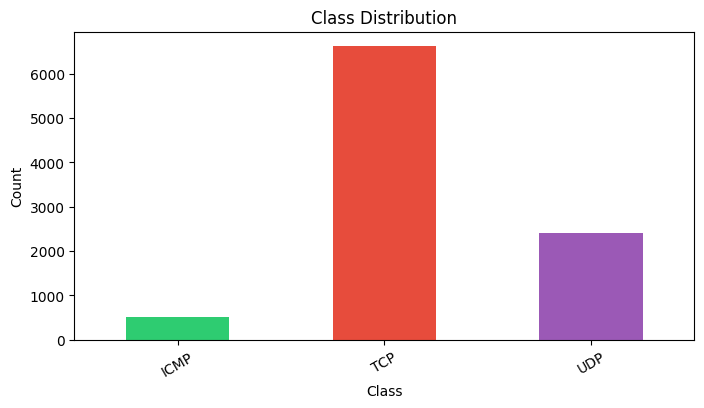

In [45]:
labels = ['ICMP', 'TCP', 'UDP']

counts = df['protocol_type'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))

counts.plot.bar(
    ax=ax,
    color=['#2ecc71', '#e74c3c', '#9b59b6']
)

ax.set_xticklabels(labels, rotation=30)
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')

plt.show()

## 6. Model Training & Baseline Results


In [48]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=20)
}
results, predictions = {}, {}

for name, m in models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    predictions[name] = yp
    results[name] = {
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall':    recall_score(y_test, yp, average='weighted'),
        'F1-Score':  f1_score(y_test, yp, average='weighted')
    }
    print(f"{name}: Acc={results[name]['Accuracy']:.4f}  Precision = {results[name]['Precision']:.4f} Recall = {results[name]['Recall']:.4f} F1={results[name]['F1-Score']:.4f}")

print("\nLabels:\n", df['attack_detected'].value_counts().sort_index())

Decision Tree: Acc=0.8160  Precision = 0.8170 Recall = 0.8160 F1=0.8163
KNN (k=5): Acc=0.7998  Precision = 0.8097 Recall = 0.7998 F1=0.7951
Logistic Reg: Acc=0.7411  Precision = 0.7403 Recall = 0.7411 F1=0.7401

Labels:
 attack_detected
0    5273
1    4264
Name: count, dtype: int64


## 7. Decision Tree — Depth Tuning


           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8747     0.8979  0.8747    0.8709
5            0.8947     0.9115  0.8947    0.8922
10           0.8926     0.9050  0.8926    0.8905
15           0.8789     0.8837  0.8789    0.8776
20           0.8543     0.8548  0.8543    0.8536
None         0.8160     0.8170  0.8160    0.8163


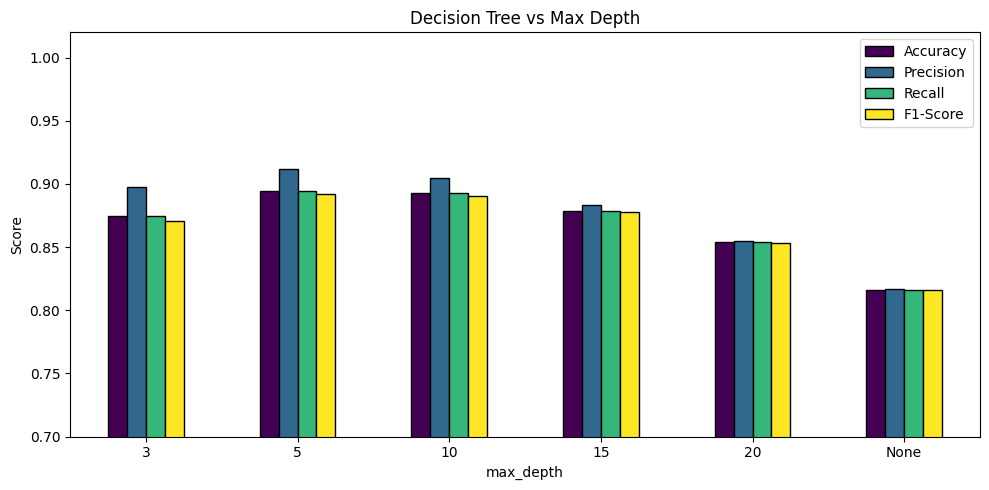

In [47]:
dt_results = []
for d in [3, 5, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=20).fit(X_train, y_train)
    yp = dt.predict(X_test)
    dt_results.append({'max_depth': str(d) or 'None',
        'Accuracy': accuracy_score(y_test, yp), 'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'), 'F1-Score': f1_score(y_test, yp, average='weighted')})

dt_df = pd.DataFrame(dt_results).set_index('max_depth')
print(dt_df.round(4))
dt_df.plot(kind='bar', figsize=(10,5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree vs Max Depth'); plt.ylabel('Score'); plt.ylim(0.7, 1.02); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 8. Classification Reports


In [50]:
target_names = ['normal activity', 'attack_detected']
for name, yp in predictions.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, yp, target_names=target_names, digits=4))


Decision Tree
                 precision    recall  f1-score   support

normal activity     0.8438    0.8190    0.8312      1055
attack_detected     0.7839    0.8124    0.7979       853

       accuracy                         0.8160      1908
      macro avg     0.8138    0.8157    0.8145      1908
   weighted avg     0.8170    0.8160    0.8163      1908


KNN (k=5)
                 precision    recall  f1-score   support

normal activity     0.7677    0.9147    0.8348      1055
attack_detected     0.8618    0.6577    0.7460       853

       accuracy                         0.7998      1908
      macro avg     0.8147    0.7862    0.7904      1908
   weighted avg     0.8097    0.7998    0.7951      1908


Logistic Reg
                 precision    recall  f1-score   support

normal activity     0.7529    0.7915    0.7717      1055
attack_detected     0.7247    0.6788    0.7010       853

       accuracy                         0.7411      1908
      macro avg     0.7388    0.7351    

## 9. Confusion Matrices


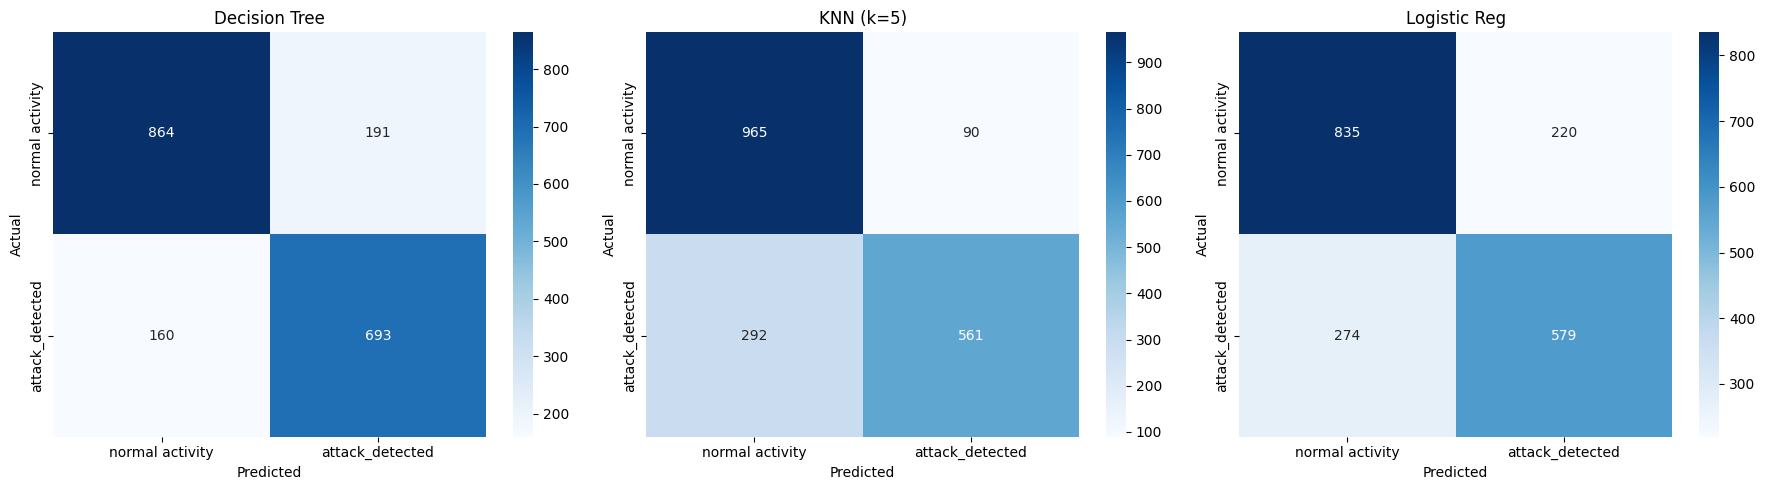

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## 10. Model Comparison


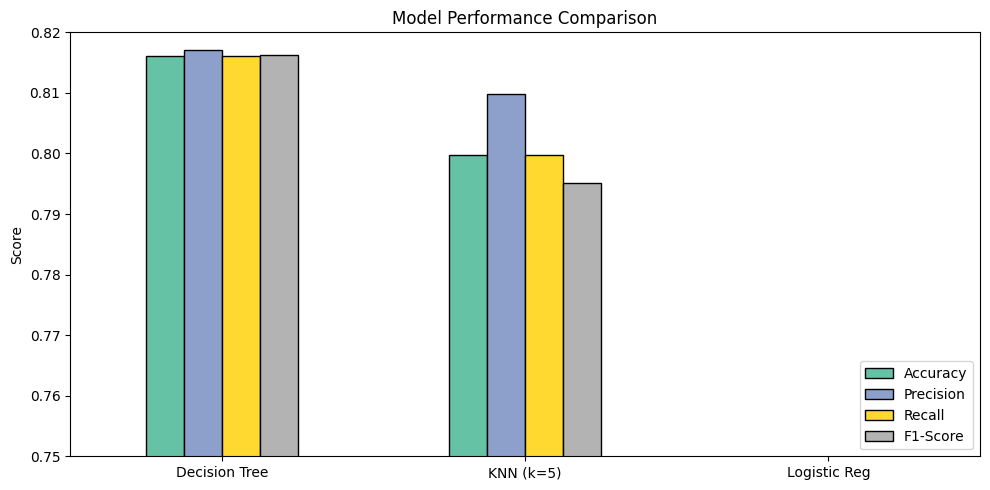


Summary:
                Accuracy  Precision  Recall  F1-Score
Decision Tree    0.8160     0.8170  0.8160    0.8163
KNN (k=5)        0.7998     0.8097  0.7998    0.7951
Logistic Reg     0.7411     0.7403  0.7411    0.7401


In [53]:
res_df = pd.DataFrame(results).T
res_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison'); plt.ylabel('Score'); plt.ylim(0.75, .82)
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print("\nSummary:\n", res_df.round(4))